Step 1: Import & Prepare Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import numpy as np


In [2]:
# Load and clean dataset
df = pd.read_csv("/content/avocado.csv")
df['Date'] = pd.to_datetime(df['Date'])

In [3]:
# National average price across all regions
df_avg = df.groupby('Date')['AveragePrice'].mean().reset_index()
df_avg = df_avg.sort_values('Date')

In [4]:
# Preview
df_avg.head()

,Date,AveragePrice
0,2015-01-04,1.301296
1,2015-01-11,1.370648
2,2015-01-18,1.391111
3,2015-01-25,1.397130
4,2015-02-01,1.247037


Step 2: Analyze Historical Trends & Seasonality

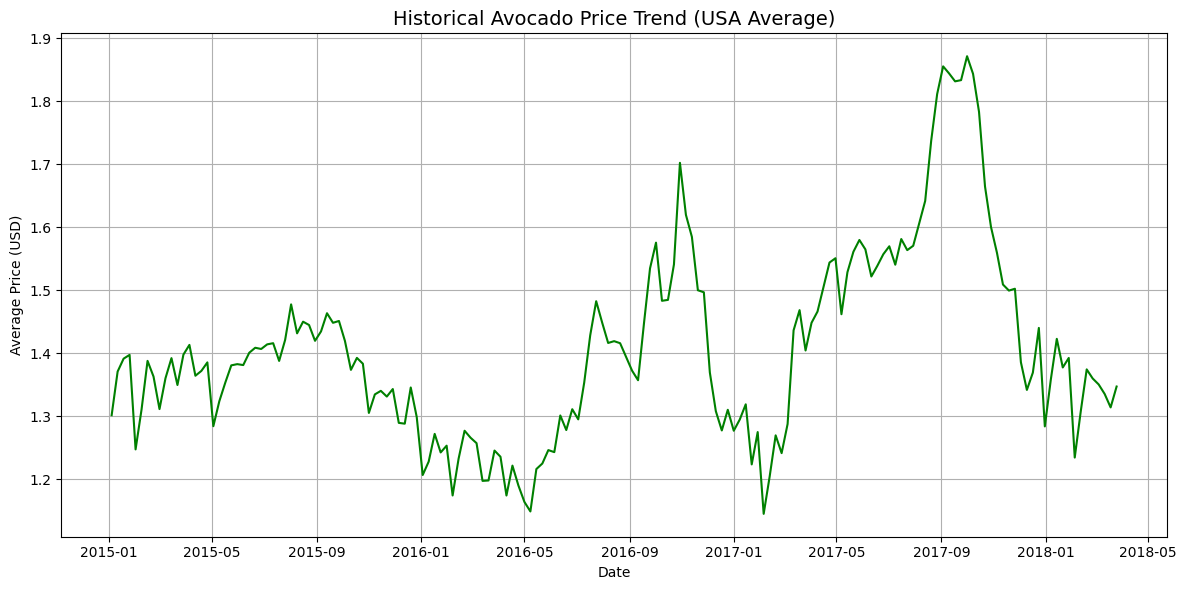

In [5]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df_avg, x='Date', y='AveragePrice', color='green')
plt.title("Historical Avocado Price Trend (USA Average)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Average Price (USD)")
plt.grid(True)
plt.tight_layout()
plt.show()


Step 3: Linear Regression Modeling for Forecasting

In [6]:
# Convert date to ordinal for regression input
df_avg['DateOrdinal'] = df_avg['Date'].map(pd.Timestamp.toordinal)

In [8]:
# Model setup
X = df_avg[['DateOrdinal']]
y = df_avg['AveragePrice']

model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [9]:
# Predictions on historical data
df_avg['PredictedPrice'] = model.predict(X)

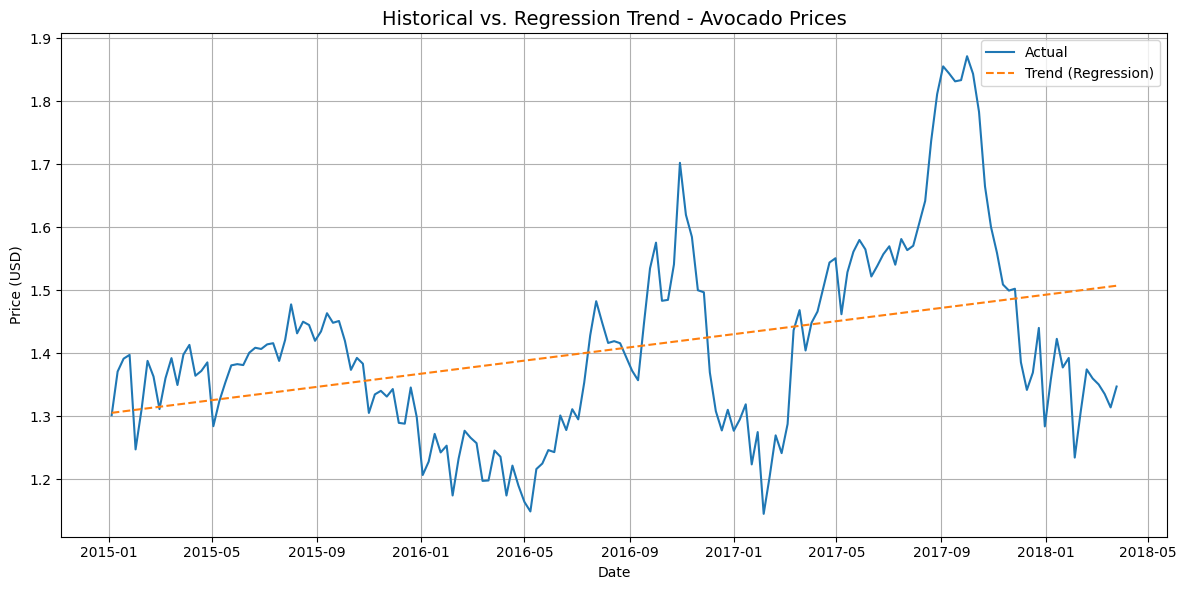

In [10]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df_avg, x='Date', y='AveragePrice', label='Actual')
sns.lineplot(data=df_avg, x='Date', y='PredictedPrice', label='Trend (Regression)', linestyle='--')
plt.title("Historical vs. Regression Trend - Avocado Prices", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Step 4: Forecasting Next 6 Months

In [11]:
# Forecast future prices
future_dates = pd.date_range(start=df_avg['Date'].max(), periods=180)
future_ordinals = future_dates.map(pd.Timestamp.toordinal).values.reshape(-1, 1)
future_prices = model.predict(future_ordinals)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [12]:
# Forecast DataFrame
forecast_df = pd.DataFrame({
    'Date': future_dates,
    'ForecastedPrice': future_prices
})

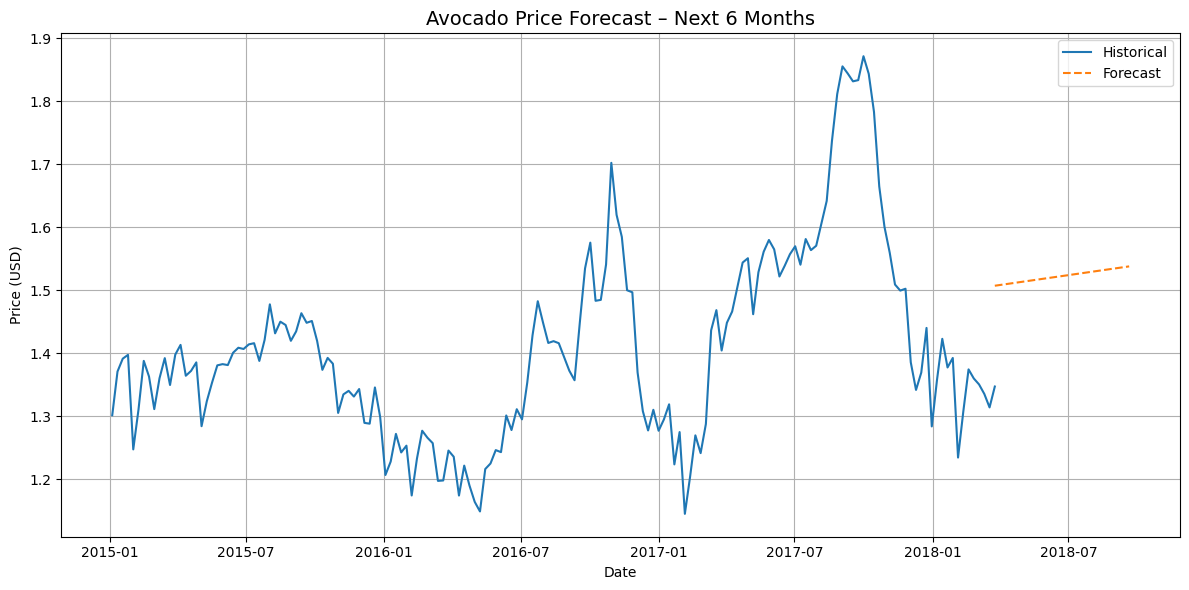

In [13]:
# Plot forecast
plt.figure(figsize=(12,6))
sns.lineplot(data=df_avg, x='Date', y='AveragePrice', label='Historical')
sns.lineplot(data=forecast_df, x='Date', y='ForecastedPrice', label='Forecast', linestyle='--')
plt.title("Avocado Price Forecast – Next 6 Months", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
# 📌 Step 5: Business Analysis Output
latest_forecast = forecast_df.head(5)
print("\n📊 Forecasted Prices (Next 5 Days):")
print(latest_forecast)

print("\n🧠 Business Analyst Summary:")
print(f"""
- Average avocado prices exhibit clear seasonality and long-term trends.
- Regression analysis shows a steady movement, useful for price planning.
- Prices are expected to {'increase' if future_prices[-1] > y.mean() else 'decrease'} slightly over the next 6 months.

🎯 Recommendations:
• Plan procurement before expected price increases.
• Monitor external risks (weather, logistics, global demand).
• Use more advanced forecasting models for high-accuracy needs (e.g., ARIMA, Prophet).
""")


📊 Forecasted Prices (Next 5 Days):
        Date  ForecastedPrice
0 2018-03-25         1.506894
1 2018-03-26         1.507066
2 2018-03-27         1.507237
3 2018-03-28         1.507409
4 2018-03-29         1.507580

🧠 Business Analyst Summary:

- Average avocado prices exhibit clear seasonality and long-term trends.
- Regression analysis shows a steady movement, useful for price planning.
- Prices are expected to increase slightly over the next 6 months.

🎯 Recommendations:
• Plan procurement before expected price increases.
• Monitor external risks (weather, logistics, global demand).
• Use more advanced forecasting models for high-accuracy needs (e.g., ARIMA, Prophet).

